In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor, plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
from sklearn.neighbors import KNeighborsClassifier

In [39]:
dataset = pd.read_csv("../datasets/subscription_dataset.csv")

In [40]:
dataset.columns = dataset.columns.str.strip()
dataset.head()

,Age,EstimatedSalary,Purchased
0,56,40342,0
1,46,121308,1
2,32,121081,1
3,25,104045,1
4,38,49698,0


In [41]:
dataset.isnull().sum()



Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

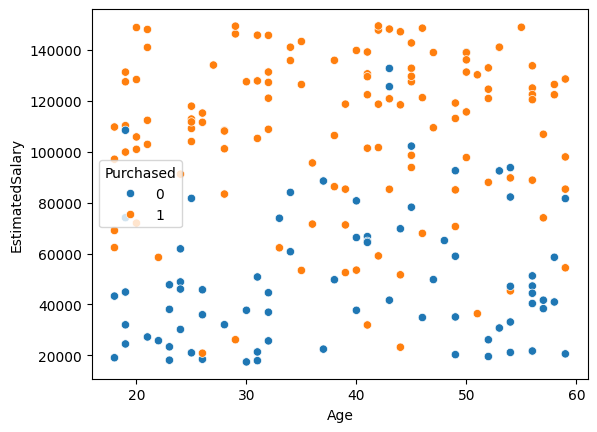

In [42]:
sns.scatterplot(x="Age",y="EstimatedSalary",data=dataset,hue="Purchased")

In [43]:
x = dataset.iloc[:,:-1]
y = dataset["Purchased"]

In [44]:
sc= StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x),columns=x.columns)

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [46]:
knn = KNeighborsClassifier(n_neighbors=21)
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",21
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [47]:
knn.score(x_test,y_test)*100

85.0

In [48]:
knn.score(x_train,y_train)*100

83.75

In [49]:
for i in range(1,30):
    knn1 = KNeighborsClassifier(n_neighbors=i)
    knn1.fit(x_train,y_train)
    print(i, knn1.score(x_train,y_train)*100,knn1.score(x_test,y_test)*100)

1 100.0 67.5
2 86.25 75.0
3 85.0 75.0
4 81.875 77.5
5 81.875 75.0
6 84.375 67.5
7 83.75 77.5
8 83.125 77.5
9 82.5 77.5
10 82.5 77.5
11 83.125 80.0
12 82.5 80.0
13 81.875 77.5
14 82.5 77.5
15 81.25 75.0
16 81.875 82.5
17 81.875 82.5
18 81.875 82.5
19 83.125 82.5
20 81.875 85.0
21 83.75 85.0
22 82.5 85.0
23 83.125 82.5
24 83.125 85.0
25 82.5 85.0
26 81.875 85.0
27 81.875 77.5
28 81.25 77.5
29 81.25 77.5


In [54]:
knn.predict([[ -0.371030  ,1.333882]])

c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([1])

In [53]:
x,y

(          Age  EstimatedSalary
 0    1.378737        -1.120218
 1    0.583388         0.851214
 2   -0.530100         0.845687
 3   -1.086844         0.430879
 4   -0.052891        -0.892410
 ..        ...              ...
 195 -1.245914        -1.176050
 196  0.821993         0.651748
 197 -1.404984         0.633803
 198 -0.848240        -0.072169
 199 -0.371030         1.333882
 
 [200 rows x 2 columns],
 0      0
 1      1
 2      1
 3      1
 4      0
       ..
 195    0
 196    1
 197    1
 198    1
 199    1
 Name: Purchased, Length: 200, dtype: int64)

c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


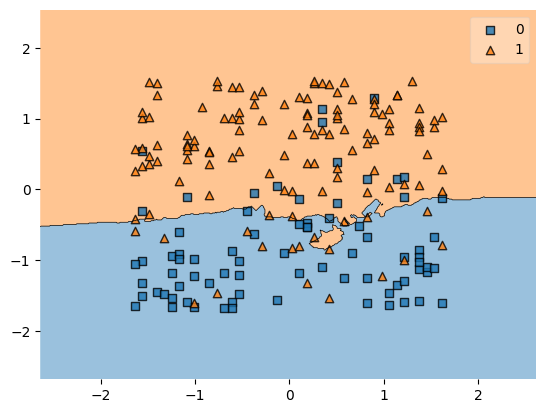

In [56]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=knn)
plt.show()